# H1 ablation: metadata only

The same measurement with the body text removed, so each passage is the
rendered metadata alone.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fsr.h1_results import (
    answer_intervals,
    answer_table,
    available,
    load_axis,
    score_intervals,
    score_table,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.45,
        "axes.edgecolor": "0.3",
        "axes.linewidth": 0.9,
    }
)

BAR_FILL = sns.color_palette("pastel")[0]
BAR_EDGE = sns.color_palette("muted")[0]
MUTED_FILL = "0.88"
MUTED_EDGE = "0.6"
RULE = "0.35"
ERROR = "0.45"
D_THRESHOLDS = ((0.2, "small"), (0.5, "medium"), (0.8, "large"))

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "nq"
FIG_DIR = ROOT / "notebooks" / "h1" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODE = "metadata_only"
PRIMARY = "with_body"
SPLIT = "test"
CHECK = "nq_val"
DESCRIPTIVE = "all"
RECORD_SETS = (SPLIT, CHECK, DESCRIPTIVE)
LABEL = {SPLIT: "test", CHECK: "nq_val", DESCRIPTIVE: "pooled"}


def save(fig, name):
    """Write the figure as a vector PDF for the thesis and a PNG to read."""
    fig.tight_layout()
    for suffix in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", bbox_inches="tight")


def dumbbell(ax, frame, column, label, order):
    """Draw one marker per mode for each model, joined by a line."""
    rows = frame.loc[order]
    y = range(len(order))
    ax.hlines(
        y, rows[(PRIMARY, column)], rows[(MODE, column)], color="0.7", lw=1.6, zorder=1
    )
    ax.scatter(
        rows[(PRIMARY, column)],
        y,
        s=58,
        color=MUTED_FILL,
        edgecolor=MUTED_EDGE,
        linewidth=0.9,
        zorder=2,
        label="with body",
    )
    ax.scatter(
        rows[(MODE, column)],
        y,
        s=58,
        color=BAR_FILL,
        edgecolor=BAR_EDGE,
        linewidth=0.9,
        zorder=3,
        label="metadata only",
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(order)
    ax.set_xlabel(label)
    ax.set_xlim(0, None)


def legend(ax):
    """Put the mode key on one panel, clear of the data."""
    ax.legend(
        loc="lower right",
        fontsize=9,
        frameon=True,
        facecolor="white",
        edgecolor="0.8",
        framealpha=0.95,
        borderpad=0.6,
    ).set_zorder(5)


modes = (PRIMARY, MODE)
cross = {m: load_axis(DATA_ROOT, SPLIT, "cross", m) for m in modes}
within = {m: load_axis(DATA_ROOT, SPLIT, "within", m) for m in modes}
print("score axis: ", ", ".join(available(DATA_ROOT, "cross", MODE)))
print("answer axis:", ", ".join(available(DATA_ROOT, "within", MODE)))

score axis:  test, nq_val, all
answer axis: test, nq_val, all


## Answer axis


In [2]:
answers = pd.concat({m: answer_table(within[m]) for m in modes}, axis=1)
answers[[(m, c) for m in modes for c in ("inconsistency_pct", "answerable_pct")]].round(
    2
)

with_body                    metadata_only               
           inconsistency_pct answerable_pct inconsistency_pct answerable_pct
model                                                                       
MiniLM-L6              14.39          87.87             21.39          48.76
MiniLM-L12             11.94          89.57             23.16          51.24
bge-base               17.67          90.74             77.05          55.67
bge-v2-m3               4.66          95.18             25.93          63.36
mxbai-v1                3.75          90.35             17.11          59.45
jina-v2                 4.90          93.22             19.56          58.67

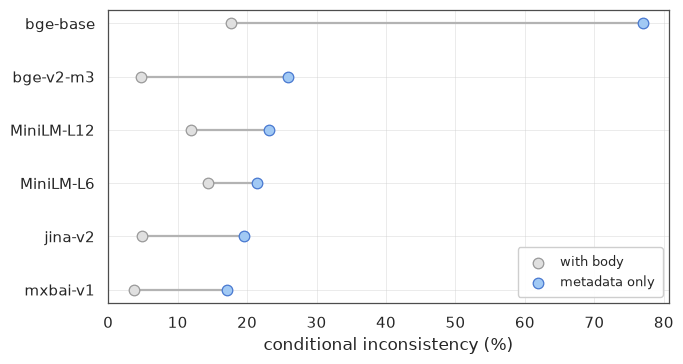

In [3]:
order = answers.sort_values((MODE, "inconsistency_pct")).index
fig, ax = plt.subplots(figsize=(7, 3.8))
dumbbell(ax, answers, "inconsistency_pct", "conditional inconsistency (%)", order)
legend(ax)
save(fig, "ablation_answer_axis")
None

Every model becomes more format-dependent without the body. bge-base is an
outlier at 77% on a base of 427 answerable queries, which indicates that its
metadata-only ranking is rarely stable across formats. The metadata block is
therefore the primary locus of the sensitivity rather than its interaction
with the surrounding prose.


## Score axis


In [4]:
gaps = {
    m: pd.Series(
        {
            label: np.mean([abs(p["mean_diff"]) for p in e["stats"]["pairwise"]])
            for label, e in zip(
                score_table(cross[m]).index, cross[m].values(), strict=True
            )
        },
        name="mean_gap",
    )
    for m in modes
}
scores = pd.concat(
    {
        m: score_table(cross[m])[["mean_abs_d", "max_abs_d"]].join(gaps[m])
        for m in modes
    },
    axis=1,
)
scores.round(3)

with_body                    metadata_only                   
           mean_abs_d max_abs_d mean_gap    mean_abs_d max_abs_d mean_gap
model                                                                    
MiniLM-L6       0.496     0.903    0.555         0.611     1.108    0.608
MiniLM-L12      0.433     0.938    0.316         0.640     1.276    0.620
bge-base        0.191     0.383    0.161         0.478     0.818    0.959
bge-v2-m3       0.279     0.452    0.158         0.230     0.593    0.144
mxbai-v1        0.404     0.650    0.122         0.415     0.718    0.196
jina-v2         0.480     0.899    0.090         0.282     0.518    0.066

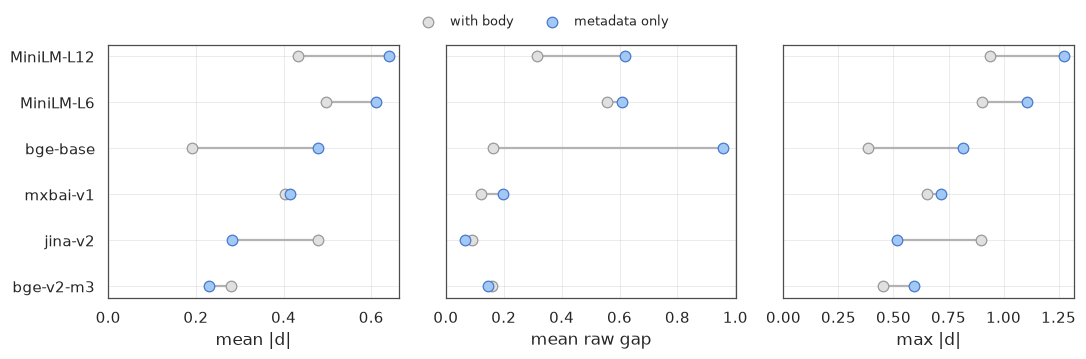

In [5]:
statistics = (
    ("mean_abs_d", "mean |d|"),
    ("mean_gap", "mean raw gap"),
    ("max_abs_d", "max |d|"),
)
order = scores.sort_values((MODE, "mean_abs_d")).index

fig, panels = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, (column, label) in zip(panels, statistics, strict=True):
    dumbbell(ax, scores, column, label, order)
fig.legend(
    *panels[0].get_legend_handles_labels(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=2,
    frameon=False,
    fontsize=9,
)
save(fig, "ablation_score_axis")
None

Removing the body does not move the score axis in a consistent direction.
Mean |d| rises on four of the six models, the raw gap on four and max |d|
on five.


### Intervals


In [6]:
pd.concat(
    {
        "score": score_intervals(cross[MODE]),
        "answer": answer_intervals(within[MODE]),
    },
    axis=1,
).round(2)

score                        answer              
           max_abs_d   low  high inconsistency_pct    low   high
model                                                           
MiniLM-L6       1.11  1.02  1.25             21.39  17.39  25.67
MiniLM-L12      1.28  1.19  1.37             23.16  19.04  27.35
bge-base        0.82  0.77  0.88             77.05  72.99  80.99
bge-v2-m3       0.59  0.52  0.67             25.93  22.03  29.81
mxbai-v1        0.72  0.64  0.79             17.11  13.77  20.56
jina-v2         0.52  0.46  0.60             19.56  15.95  23.32

## Robustness checks

In [7]:
rises = pd.DataFrame(
    {
        LABEL[s]: {
            "answer axis": int(
                (
                    answer_table(load_axis(DATA_ROOT, s, "within", MODE))[
                        "inconsistency_pct"
                    ]
                    > answer_table(load_axis(DATA_ROOT, s, "within", PRIMARY))[
                        "inconsistency_pct"
                    ]
                ).sum()
            ),
            "score axis, mean |d|": int(
                (
                    score_table(load_axis(DATA_ROOT, s, "cross", MODE))["mean_abs_d"]
                    > score_table(load_axis(DATA_ROOT, s, "cross", PRIMARY))[
                        "mean_abs_d"
                    ]
                ).sum()
            ),
            "score axis, max |d|": int(
                (
                    score_table(load_axis(DATA_ROOT, s, "cross", MODE))["max_abs_d"]
                    > score_table(load_axis(DATA_ROOT, s, "cross", PRIMARY))[
                        "max_abs_d"
                    ]
                ).sum()
            ),
        }
        for s in RECORD_SETS
    }
)
rises

,test,nq_val,pooled
answer axis,6,6,6
"score axis, mean |d|",4,4,4
"score axis, max |d|",5,5,5


Every model becomes more format-dependent without the body on all three
record sets. The score axis moves in both directions on all three, and the
count depends on the statistic.

`pooled` is `train`, `dev` and `test` together, all drawn from the NQ train
split. `nq_val` comes from the NQ validation split which is an independent set of
articles.